In [34]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [35]:
# Load the Advertising dataset

url = "https://raw.githubusercontent.com/selva86/datasets/master/Advertising.csv"

df = pd.read_csv(url)

# Display the first 5 rows
df.head()

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [36]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [37]:
# Check the dataset information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   radio      200 non-null    float64
 2   newspaper  200 non-null    float64
 3   sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [38]:
# Check for missing/null values

print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
TV           0
radio        0
newspaper    0
sales        0
dtype: int64


In [39]:
# Display descriptive statistics

df.describe()

,TV,radio,newspaper,sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


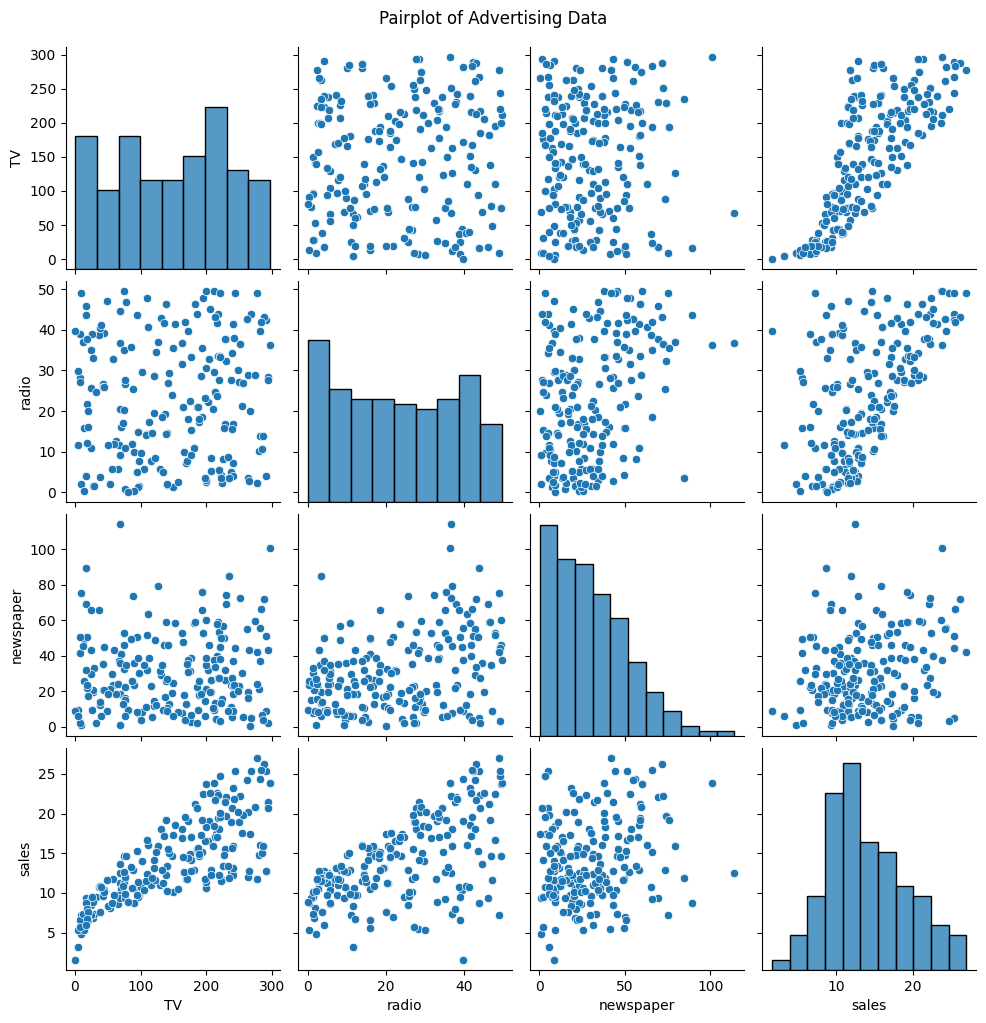

In [40]:
# Pairplot to visualize relationships between advertising channels and sales

sns.pairplot(df)

plt.suptitle("Pairplot of Advertising Data", y=1.02)

plt.show()

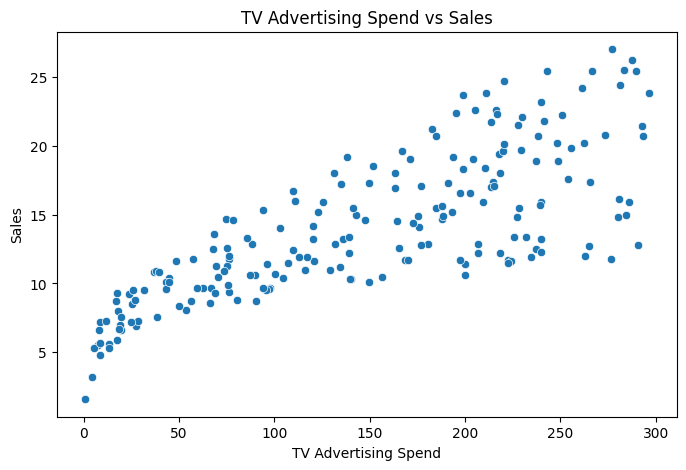

In [41]:
# Scatter plot: TV advertising vs Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="TV",
    y="sales",
    data=df
)

plt.title("TV Advertising Spend vs Sales")
plt.xlabel("TV Advertising Spend")
plt.ylabel("Sales")

plt.show()

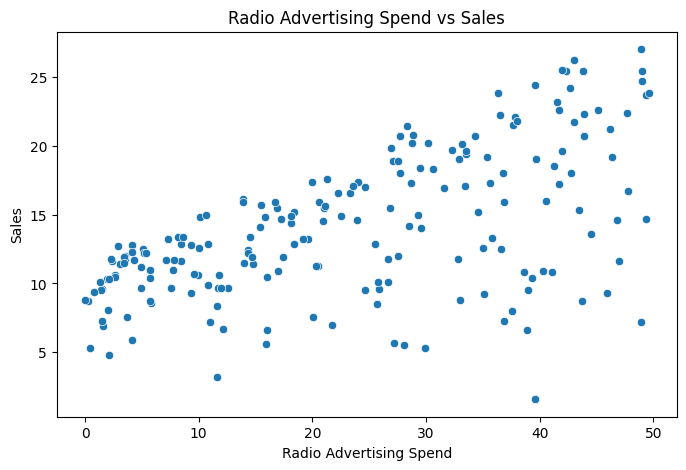

In [42]:
# Scatter plot: Radio advertising vs Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="radio",
    y="sales",
    data=df
)

plt.title("Radio Advertising Spend vs Sales")
plt.xlabel("Radio Advertising Spend")
plt.ylabel("Sales")

plt.show()

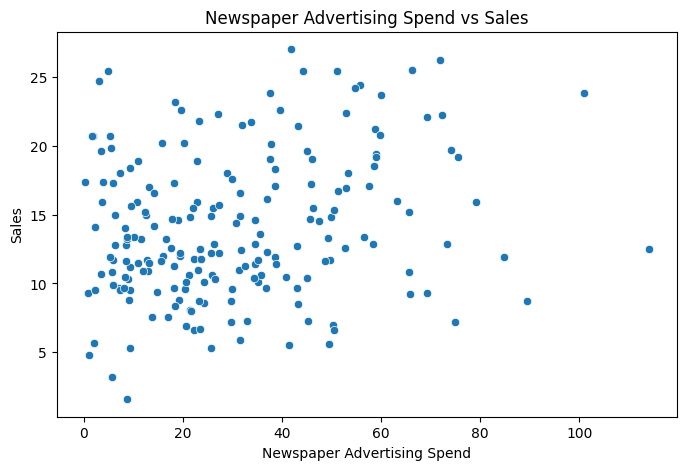

In [43]:
# Scatter plot: Newspaper advertising vs Sales

plt.figure(figsize=(8, 5))

sns.scatterplot(
    x="newspaper",
    y="sales",
    data=df
)

plt.title("Newspaper Advertising Spend vs Sales")
plt.xlabel("Newspaper Advertising Spend")
plt.ylabel("Sales")

plt.show()

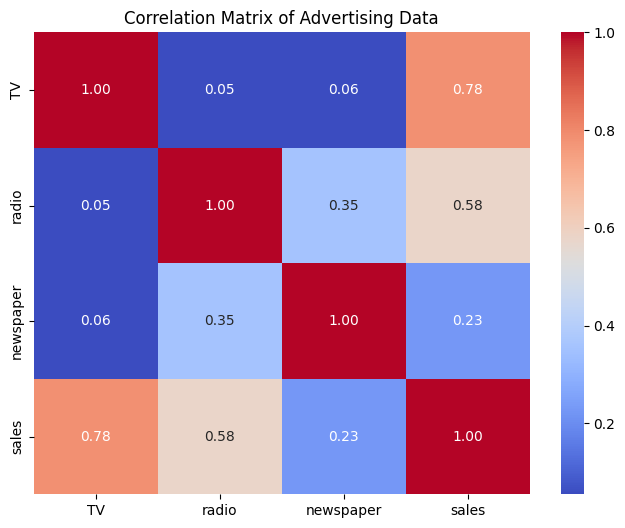

In [44]:
# Correlation matrix

correlation_matrix = df.corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Advertising Data")

plt.show()

In [45]:
from sklearn.model_selection import train_test_split

# Select input features and target
X = df[["TV", "radio", "newspaper"]]
y = df["sales"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 160
Testing samples: 40


In [46]:
from sklearn.linear_model import LinearRegression

# Create the Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train, y_train)

# Make predictions on the test data
y_pred_linear = linear_model.predict(X_test)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [47]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred_linear)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression Performance")
print("-----------------------------")
print("MAE :", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²  :", round(r2, 3))

Linear Regression Performance
-----------------------------
MAE : 1.461
RMSE: 1.782
R²  : 0.899


In [48]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Regressor trained successfully!")

Random Forest Regressor trained successfully!


In [49]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate Random Forest evaluation metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("MAE :", round(mae_rf, 3))
print("RMSE:", round(rmse_rf, 3))
print("R²  :", round(r2_rf, 3))

Random Forest Performance
-------------------------
MAE : 0.62
RMSE: 0.769
R²  : 0.981


In [50]:
# Compare model performance

comparison = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae, mae_rf],
    "RMSE": [rmse, rmse_rf],
    "R²": [r2, r2_rf]
})

comparison

,Model,MAE,RMSE,R²
0,Linear Regression,1.460757,1.781600,0.899438
1,Random Forest,0.620100,0.768591,0.981284


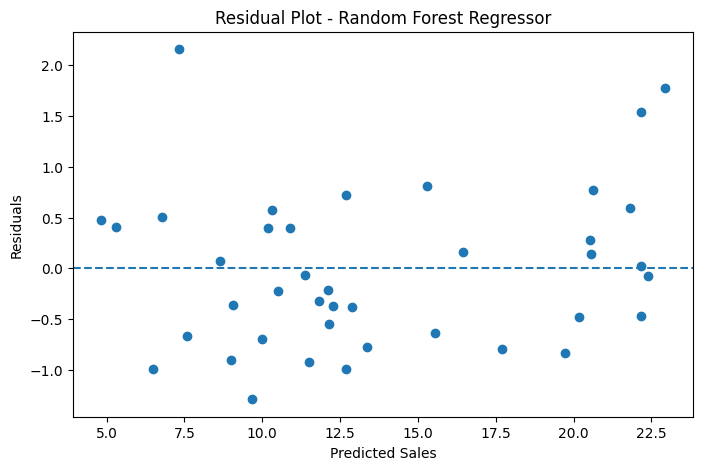

In [51]:
# Calculate residuals
residuals = y_test - y_pred_rf

# Plot residuals
plt.figure(figsize=(8, 5))

plt.scatter(y_pred_rf, residuals)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Sales")
plt.ylabel("Residuals")
plt.title("Residual Plot - Random Forest Regressor")

plt.show()


In [52]:
# Feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

Feature Importance:


,Feature,Importance
0,TV,0.624810
1,radio,0.362201
2,newspaper,0.012989


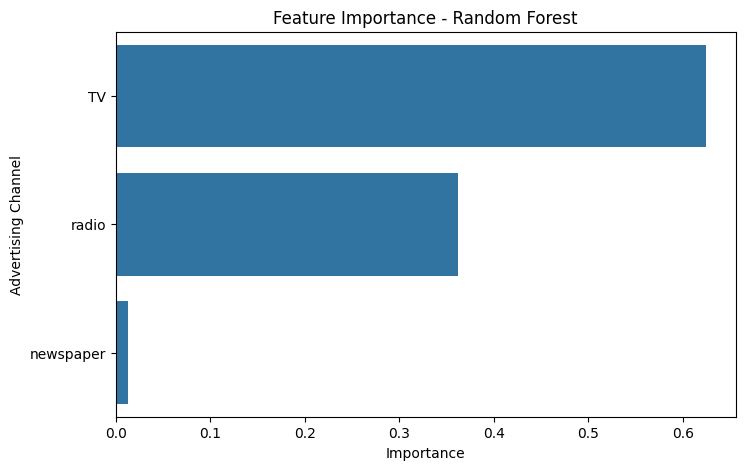

In [53]:
# Visualize feature importance

plt.figure(figsize=(8, 5))

sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_importance
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Advertising Channel")

plt.show()

## Interpretation

The Random Forest feature importance analysis shows that TV advertising has the highest importance in predicting sales, with an importance score of approximately 0.625.

Radio is the second most important feature with an importance score of approximately 0.362, while Newspaper has a very low importance of approximately 0.013.

Therefore, TV advertising appears to have the greatest influence on sales among the three advertising channels in this dataset.

## Conclusion

In this project, a machine learning approach was used to predict product sales based on advertising expenditure across TV, Radio, and Newspaper channels.

The dataset was explored using descriptive statistics, visualizations, scatter plots, and a correlation heatmap. The data was then divided into training and testing sets.

Two regression models were trained:
- Linear Regression
- Random Forest Regressor

The models were evaluated using MAE, RMSE, and R² score. Random Forest performed better than Linear Regression, achieving an R² score of 0.981, compared with 0.899 for Linear Regression.

The Random Forest feature importance analysis showed that TV advertising had the highest importance, followed by Radio, while Newspaper had very low importance.

Overall, Random Forest was selected as the best-performing model for this sales prediction task.